source .vvenv/bin/activate

deactivate

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


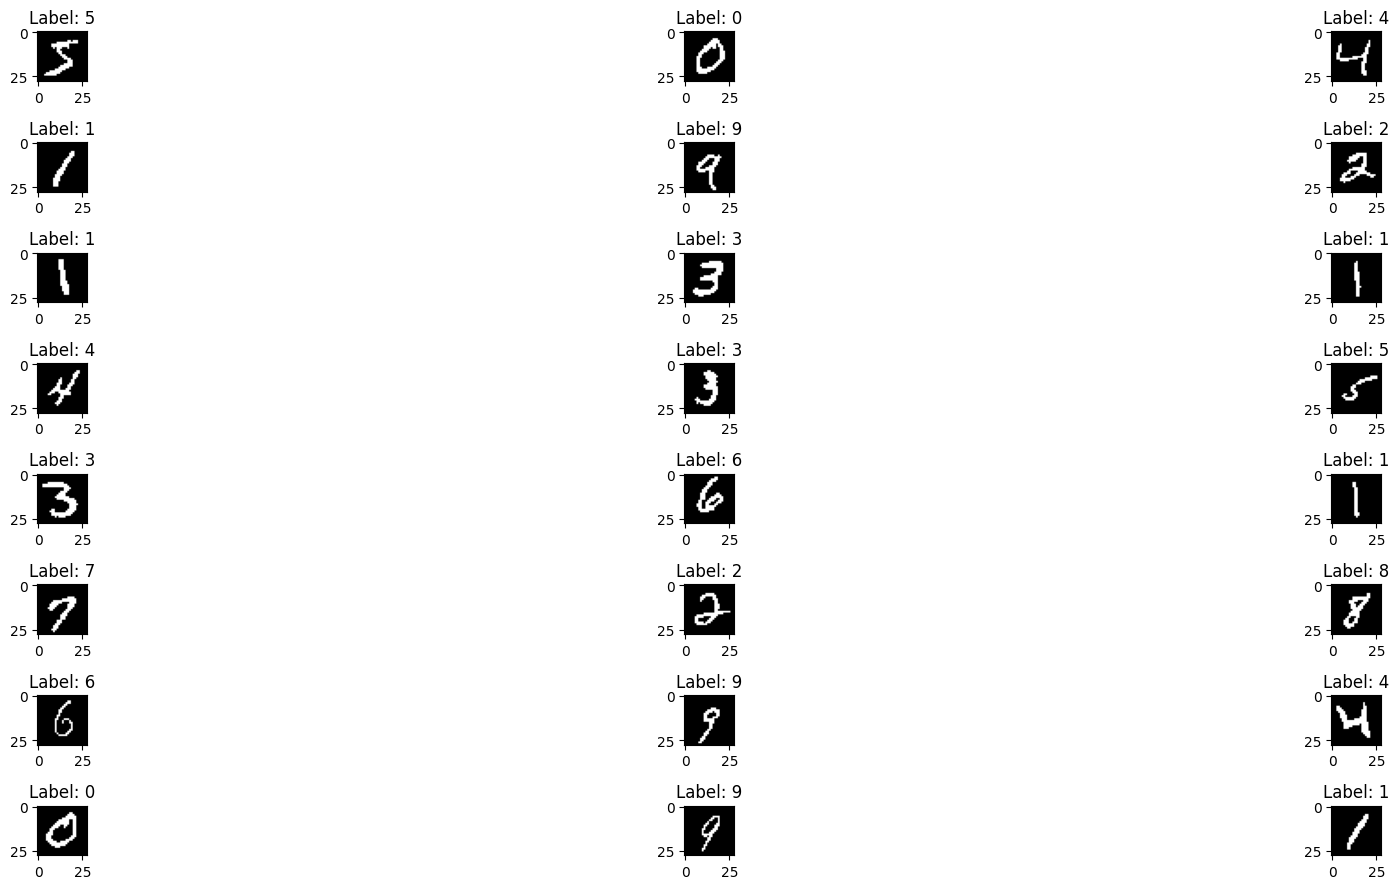

84.3
785
float64


In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

with np.load("mnist (8).npz") as data:
    x_train = data["x_train"][:5000] / 255.0
    x_train[x_train > 0.5] = 1.0
    x_train[x_train <= 0.5] = 0.0
    y_train = data["y_train"][:5000]

    x_test = data["x_test"][:5000] / 255.0
    x_test[x_test > 0.5] = 1.0
    x_test[x_test <= 0.5] = 0.0

    y_test = data["y_test"][:5000]

print(x_train)

def load_images(width, height, features, labels):
    fig, axes = plt.subplots(height, width, figsize=(height*3, width*3))
    axes = axes.flatten()
    for i in range(len(axes)):
        axes[i].imshow(x_train[i], cmap="gray")
        axes[i].set_title(f"Label: {labels[i]}")
    plt.tight_layout()
    plt.show()

load_images(3, 8, x_train, y_train)

model = LogisticRegression(max_iter=1000)
reshaped_x_train = x_train.reshape(5000, 784)
model.fit(reshaped_x_train, y_train)
reshaped_x_test = x_test.reshape(5000, 784)
predictions = model.predict(reshaped_x_test)

accuracy = int(np.mean(y_test == predictions) * 10000)/100 # takes the average value of a new array where each correponding item is true if the prediction is correct and false is its not
print(accuracy)

incorrect_indexes = np.where(y_test != predictions)[0] # returns an array of indexes where the incorrect predictions happen
print(len(incorrect_indexes))

def quick_load(indexes, features, labels):
  for i in indexes:
    plt.imshow(features[i], cmap="gray")
    plt.title(f"Correct Answer: {labels[i]}, Guess: {predictions[i]}")
    plt.show()

print(x_train.dtype)
#quick_load(incorrect_indexes, x_test, y_test)


In [8]:
import cv2
def prediction(img, model):
    img = cv2.resize(img, (28, 28))
    img = img/255
    img = img.reshape(1, 784)


    result = model.predict(img)[0]
    prob = model.predict_proba(img)
    prob = np.amax(prob)


    if prob < 0.75:
        result = 0
        prob = 0

        
    return result, prob

In [ ]:
print(cv2.__version__)

cap = cv2.VideoCapture(0)


WIDTH = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
HEIGHT = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)


box_center_x = WIDTH//2
box_center_y = HEIGHT//2
box_size = [60, 60]

cv2.namedWindow("input", cv2.WINDOW_NORMAL)
cv2.moveWindow("input", 50, 150)

# Our main loop
while True:

    is_true, frame = cap.read() # reads the webcam


    box_coords = (
        (int(box_center_x-box_size[0]//2), int(box_center_y-box_size[1]//2)),
        (int(box_center_x+box_size[0]//2), int(box_center_y+box_size[1]//2))
    )
    box = frame[box_coords[0][1]:box_coords[1][1], box_coords[0][0]:box_coords[1][0]]



    # Convert to grayscale
    box = cv2.bitwise_not(cv2.cvtColor(box, cv2.COLOR_BGR2GRAY))
    box = cv2.resize(box, (28, 28), interpolation=cv2.INTER_AREA)


    # Convert to pure black and white
    theshold_num, box = cv2.threshold(box, 80, 255, cv2.THRESH_BINARY)

    
    threshold = np.where(box>0) # gives us the coords of all the pixels where the vlaue is greater than 0
    if len(threshold[0]) > 0: # safety check so we dont get an error
        top = threshold[0].min()
        bottom = threshold[0].max()
        left = threshold[1].min()
        right = threshold[1].max()

        box = box[top:bottom+1, left:right+1]
        height, width = box.shape
        
        scale = (20/28)*box_size[0] / max(width, height)
        height, width = max(1, int(height*scale)), max(1, int(width*scale))
        box = cv2.resize(box.astype("uint8"), (width, height), interpolation=cv2.INTER_AREA).astype("float64")


        new_canvas = np.zeros((box_size[1], box_size[0]),dtype=np.float64)
        start_y = (box_size[1] - height) // 2
        start_x = (box_size[0] - width) // 2

        new_canvas[start_y:(start_y+height), start_x:(start_x+width)] = box
        box = new_canvas
        
        # model = LogisticRegression(max_iter=2000)
        # model.fit(reshaped_x_train, y_train)
        result, prob = prediction(box, model)
    else:
        result, prob = "None", 0.0
    color = (0, 0, 255) if prob == 0 else (0, 255, 0)
    cv2.putText(frame, f"Prediction: {result}", (40, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 255), 2, cv2.LINE_AA)
    cv2.putText(frame, f"Probability: {prob:.2f}", (40, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 255), 2, cv2.LINE_AA)
    cv2.rectangle(frame, box_coords[0], box_coords[1], color, 3)
    cv2.imshow("cropped", box)
    cv2.imshow("input", frame)
    key = cv2.waitKey(1) & 0xFF
    if key == 27:
        break
    elif key == ord('w'):
        box_center_y -= 10
    elif key == ord('s'):
        box_center_y += 10
    elif key == ord('d'):
        box_center_x += 10
    elif key == ord('a'):
        box_center_x -= 10
    elif key == ord('q'):
        box_size[1] = int(box_size[1] * 0.95)
        box_size[0] = int(box_size[0] * 0.95)
    elif key == ord('e'):
        box_size[1] = int(box_size[1] / 0.95)
        box_size[0] = int(box_size[0] / 0.95)

cap.release()
cv2.destroyAllWindows()
for i in range(1, 5):
    cv2.waitKey(1)

4.13.0
